In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/Python


con = sqlite3.connect('db.sqlite3')
cur = con.cursor()


cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cur.fetchall()
print(f"Знайдені таблиці в базі даних:\n{tables}")

query = (
    '''Select
         oit.quantity
         ,rp.name
         ,rp.price
         ,ro.datetime
From restaurant_orderitem as oit
Inner join restaurant_order ro
         ON oit.order_id = ro.id
Inner join restaurant_product rp
         ON oit.product_id = rp.id
         ''')
pre_df = pd.read_sql_query(query, con)
con.close()

pre_df.to_csv('combined_restaurant_data.csv', index=False, encoding="utf-8")

df = pd.read_csv("combined_restaurant_data.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Python
Знайдені таблиці в базі даних:
[('sqlite_sequence',), ('restaurant_orderitem',), ('restaurant_product',), ('restaurant_order',)]


In [11]:
df.head()

,quantity,name,price,datetime
0,2,Plain Papadum,0.80,2019-08-03 20:25:00
1,1,King Prawn Balti,12.95,2019-08-03 20:25:00
2,1,Garlic Naan,2.95,2019-08-03 20:25:00
3,1,Mushroom Rice,3.95,2019-08-03 20:25:00
4,1,Paneer Tikka Masala,8.95,2019-08-03 20:25:00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74818 entries, 0 to 74817
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   quantity  74818 non-null  int64  
 1   name      74818 non-null  object 
 2   price     74818 non-null  float64
 3   datetime  74818 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ MB


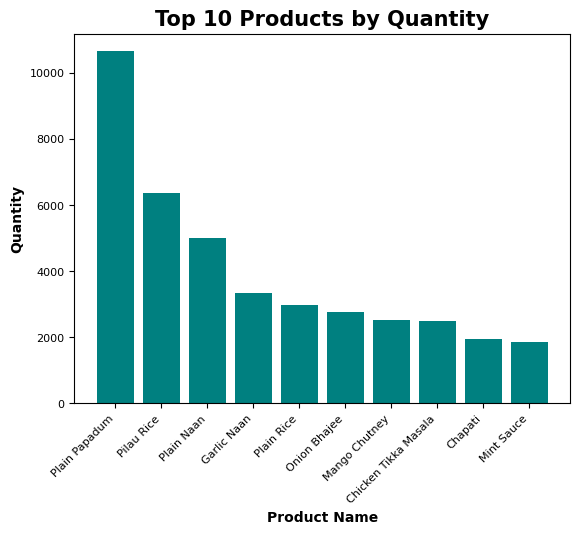

In [12]:
groupping = df.groupby('name')['quantity'].sum().sort_values(ascending=False).head(10)

plt.bar(
          groupping.index
        , groupping.values
        , color='teal'
        )
plt.title(
    'Top 10 Products by Quantity'
    , fontsize = 15
    , fontweight='bold'

    )
plt.xlabel(
    'Product Name'
    , fontweight='bold'
    )
plt.ylabel(
    'Quantity'
    , fontweight='bold'
    )
plt.xticks(
    fontsize=8
    , rotation=45
    , ha='right'
    )
plt.yticks(
    fontsize=8
)
plt.show()

**ТОП 3 найпопулярніші продукти за кількістю продажів:**

- Plain Papadum
- Pilau Rice
- Plain Naan

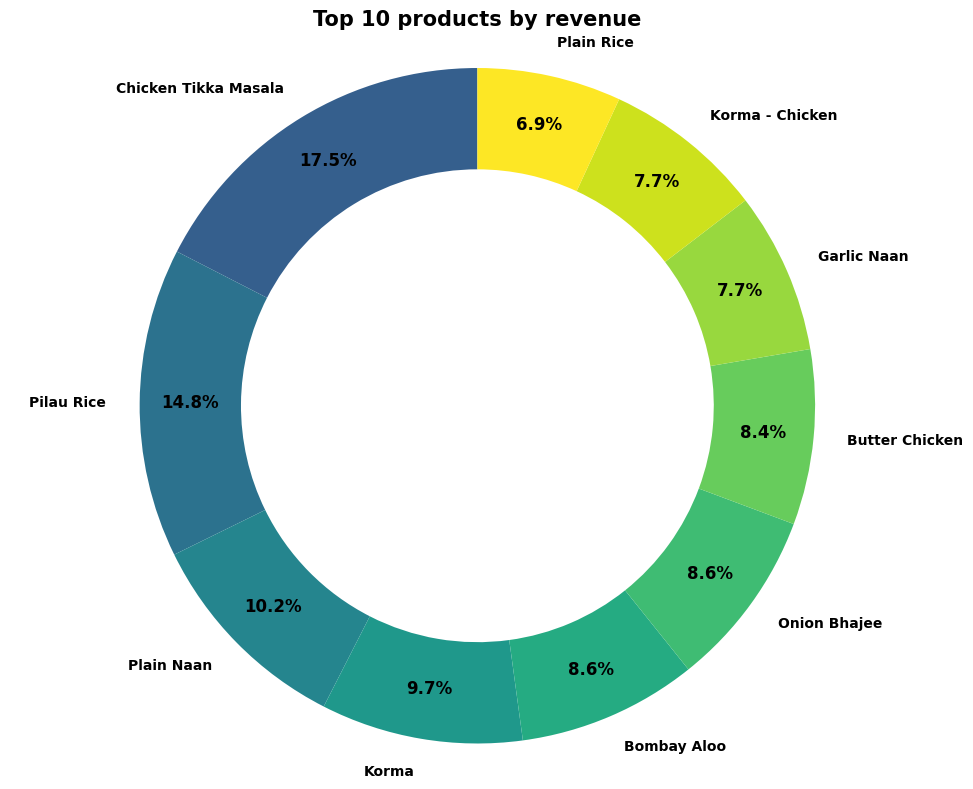

In [13]:
df['item_price'] = df['price'] * df['quantity']

groupping_price = df.groupby('name')['item_price'].sum().sort_values(ascending=False).head(10)


fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    groupping_price.values,
    labels=groupping_price.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    colors=plt.cm.viridis(np.linspace(0.3, 1, len(groupping_price))),
    wedgeprops=dict(width=0.3)
)


ax.axis('equal')


ax.set_title(
    'Top 10 products by revenue'
    , fontsize=15
    , fontweight='bold'
)


for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')


for text in texts:
    text.set_fontsize(10)
    text.set_fontweight('bold')

plt.tight_layout()
plt.show()

**ТОП 3 найпопулярніші продукти за прибутком:**

- Chicken Tikka Masala
- Pilau Rice
- Plain Naan

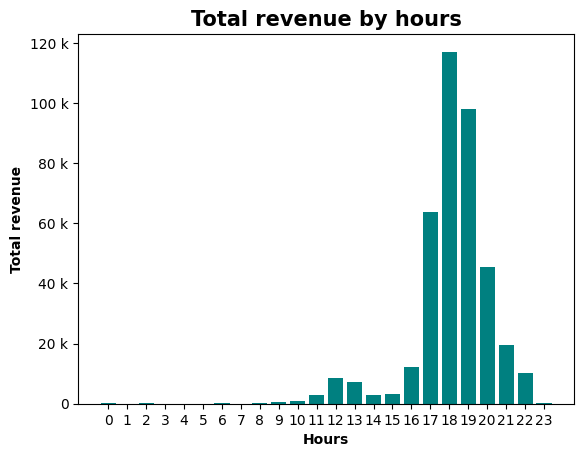

In [14]:
import matplotlib.ticker as ticker
df['datetime']= pd.to_datetime(df['datetime'])
df['hours'] = df['datetime'].dt.hour

groupping_hours = df.groupby('hours')['price'].sum().sort_values(ascending=False)

plt.bar(
    groupping_hours.index
    , groupping_hours.values
    , color='teal'
)
plt.title(
    'Total revenue by hours'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    'Hours'
    , fontweight='bold'
)
plt.ylabel(
    'Total revenue'
    , fontweight='bold'
)
plt.xticks(
    np.arange(0, 24,1)
)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.show()

Найпопулярніші години в які люди приносять найбільше прибуток з 17 до 20

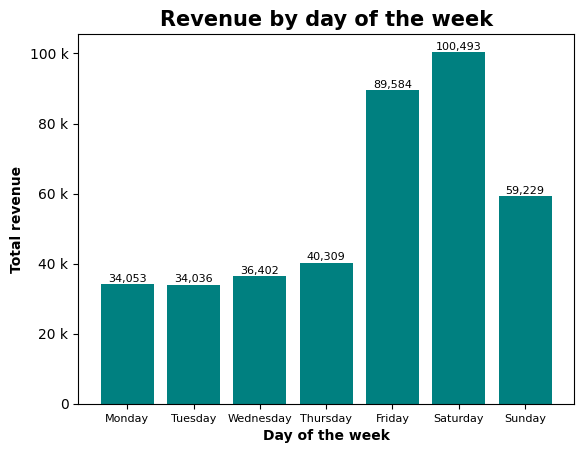

In [16]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['day_week'] = df['datetime'].dt.day_name()
days= ['Monday','Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_week']= pd.Categorical(df['day_week'], categories=days, ordered=True)
groupping_day = df.groupby('day_week', observed=False)['price'].sum()

bars = plt.bar(
    groupping_day.index
    , groupping_day.values
    , color='teal'
)
plt.title(
    'Revenue by day of the week'
    ,fontsize=15
    ,fontweight='bold'
    )
plt.xlabel(
    'Day of the week'
    ,fontweight= 'bold'

)
plt.ylabel(
    'Total revenue'
    ,fontweight='bold'
)
plt.xticks(
    fontsize=8

)

for bar in bars:
    plt.text(
        bar.get_x() +bar.get_width()/2
        , bar.get_height() + 100
        , f'{bar.get_height():,.0f}'
        , ha='center'
        , va='bottom'
        , fontsize=8
    )

plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.show()

На діаграмі можна побачити,що у п'ятницю та субботу прибуток значно вище,ніж у інші дні

##**Висновки:**

Проаналізувавши поведінку клієнтів можна відмітити,що  прибуток у ресторані у п'ятницю та у суботу більш ніж удвічі перевищує показники звичайних буднів. Неділя тримається на середньому рівні, виступаючи плавним переходом до робочого тижня.

Найприбутковіший час протягом доби - 18:00. Загалом , вечірній проміжок з 17:00 до 21:00 генерує основну частину денного доходу ресторану.
Будні дні та час до 17:00 показують помітний спад активності.

####**Рекомендації:**
1. У вечірній час із п'ятниці по суботу (з 17:00 до 21:00) закладу критично важливо задіяти максимальну кількість персоналу на кухні та в залі. Це допоможе зберегти високу швидкість обслуговування при великому потоці людей і залишити клієнтів задоволеними.

 2. Щоб залучити людей у «тихі години», варто впровадити спеціальні пропозиції для буднів: наприклад, бізнес-ланчі чи комбо-обіди до 17:00, або ж акції.

**ТОП 3 найпопулярніші продукти за кількістю продажів:**
1. Plain Papadum
2. Pilau Rice
3. Plain Naan

**ТОП 3 найпопулярніші продукти за прибутком:**
1. Chicken Tikka Masala
2. Pilau Rice
3. Plain Naan

Головним драйвером прибутку є Chicken Tikka Masala . Попри те, що її замовляють рідше, ніж Plain Papadum, завдяки вищій ціні вона приносить ресторану найбільше грошей. Рис (Pilau Rice) та хліб (Plain Naan) утримують баланс — вони лідирують і в кількості, і в грошах.

####**Рекомендації:**
Оскільки Plain Papadum є найпопулярнішими за кількістю, їх можна використовувати як «магніт». Наприклад, дарувати їх безкоштовно при замовленні найприбутковішої страви — Chicken Tikka Masala, або ж створювати сети (Масала + Pilau Rice + Plain Naan) за вигіднішою ціною. Це стимулюватиме відвідувачів витрачати більше за один візит.